# Análisis de insights — Ecommerce

Carga del tablón analítico y métricas de embudo de eventos (base: **view** = 100 %).

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns


In [21]:
# cargar tablon_analitico.pickle en df
ruta_pickle = Path('..') / 'datos' / 'intermedios' / 'tablon_analitico.pickle'
df = pd.read_pickle(ruta_pickle.resolve())

## Porcentajes de eventos (view = 100 %)

Se interpreta **view** como referencia. 

In [22]:
# Calcular el total de 'view' como base 100%
total_view = df.evento.value_counts().get('view', 0)

# Calcular el total de 'cart'
total_cart = df.evento.value_counts().get('cart', 0)

# Calcular el total de 'remove_from_cart'
total_remove = df.evento.value_counts().get('remove_from_cart', 0)

# Calcular el total de 'purchase'
total_purchase = df.evento.value_counts().get('purchase', 0)

# Porcentajes
porcentaje_cart_sobre_view = (total_cart / total_view) * 100 if total_view else 0
porcentaje_remove_sobre_cart = (total_remove / total_cart) * 100 if total_cart else 0
porcentaje_purchase_sobre_cart = (total_purchase / total_cart) * 100 if total_cart else 0

# Mostrar resultados
print(f"Cart/View: {porcentaje_cart_sobre_view:.2f}%")
print(f"Remove_from_cart/Cart: {porcentaje_remove_sobre_cart:.2f}%")
print(f"Purchase/Cart: {porcentaje_purchase_sobre_cart:.2f}%")



Cart/View: 59.75%
Remove_from_cart/Cart: 71.42%
Purchase/Cart: 22.20%


In [23]:
# Es mejor utilizar el método get para obtener el valor de un evento, porque si el evento no existe, devuelve 0.
df.evento.value_counts().get('view', 0)

np.int64(961558)

In [24]:
# si el evento no existe, devuelve un error. Evitamos este método.
df.evento.value_counts()['view']

np.int64(961558)

In [25]:
# Crear el DataFrame del funnel y modificamos todos los porcentajes sobre visualizaciones para que tenga forma de embudo.
funnel_data = {
    'evento': ['Visualizaciones', 'Añadir a carrito', 'Sacar de carrito', 'Comprar'],
    'porcentaje': [
        100,
        (total_cart / total_view) * 100 if total_view else 0,
        (total_remove / total_view) * 100 if total_view else 0,
        (total_purchase / total_view) * 100 if total_view else 0
    ]
}

df_funnel = pd.DataFrame(funnel_data)
print(df_funnel)

             evento  porcentaje
0   Visualizaciones  100.000000
1  Añadir a carrito   59.751674
2  Sacar de carrito   42.676261
3           Comprar   13.266386


In [26]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y=df_funnel['evento'],
    x=df_funnel['porcentaje'],
    textinfo='text',
    texttemplate='%{value:.1f}%',
))
fig.update_layout(title="Gráfico de Funnel de Conversión")
from IPython.display import display
display(fig)

In [27]:
df.groupby(['sesion','evento'])['producto'].count()

sesion                                evento
0000597b-de39-4a77-9fe5-02c8792ca14e  view      3
0000645a-8160-4a3d-91bf-154bff0a22e3  view      2
000090e1-da13-42b1-a31b-91a9ee5e6a88  view      1
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b  view      1
0000de26-bd58-42c9-9173-4763c76b398e  view      1
                                               ..
ffff6695-b64d-4a67-aa14-34b3b7f63c3f  view      2
ffff7d69-b706-4c64-9d6d-da57a04bc32b  view      1
ffff8044-2a22-4846-8a72-999e870abbe9  view      1
ffff91d4-7879-4a4b-8b26-c67915a27dc8  view      1
ffffbe0a-d2c2-47c7-afab-680bfdfda50d  view      1
Name: producto, Length: 581763, dtype: int64

In [28]:
#pasamos evento a columnas
sesiones = df.groupby(['sesion','evento'])['producto'].count().unstack().fillna(0)
sesiones

evento,cart,purchase,remove_from_cart,view
sesion,,,,
0000597b-de39-4a77-9fe5-02c8792ca14e,0.0,0.0,0.0,3.0
0000645a-8160-4a3d-91bf-154bff0a22e3,0.0,0.0,0.0,2.0
000090e1-da13-42b1-a31b-91a9ee5e6a88,0.0,0.0,0.0,1.0
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b,0.0,0.0,0.0,1.0
0000de26-bd58-42c9-9173-4763c76b398e,0.0,0.0,0.0,1.0
...,...,...,...,...
ffff6695-b64d-4a67-aa14-34b3b7f63c3f,0.0,0.0,0.0,2.0
ffff7d69-b706-4c64-9d6d-da57a04bc32b,0.0,0.0,0.0,1.0
ffff8044-2a22-4846-8a72-999e870abbe9,0.0,0.0,0.0,1.0


In [29]:
sesiones.mean()

evento
cart                1.288066
purchase            0.285983
remove_from_cart    0.919972
view                2.155699
dtype: float64

In [30]:
# Reordenamos el dataset con más sentido desde le punto de vista del proceso del funnel
sesiones = sesiones[['view','cart','remove_from_cart','purchase']]

In [31]:
sesiones.mean()

evento
view                2.155699
cart                1.288066
remove_from_cart    0.919972
purchase            0.285983
dtype: float64

**Insight 1:**

Datos actuales de los principales eventos en porcentaje, que nos sirven como baseline para las futuras acciones de mejora:

view               2.16

cart               1.29

remove_from_cart   0.92

purchase           0.29

In [32]:
eventos_hora = df.groupby(['hora','evento'])['producto'].count().unstack().fillna(0)
eventos_hora = eventos_hora[['view','cart','remove_from_cart','purchase']]
eventos_hora.head()

evento,view,cart,remove_from_cart,purchase
hora,,,,
0,8731,6475,3238,962
1,7280,5555,3930,1128
2,8378,6433,3509,1220
3,11807,8544,5331,1535
4,18365,11242,8095,2389


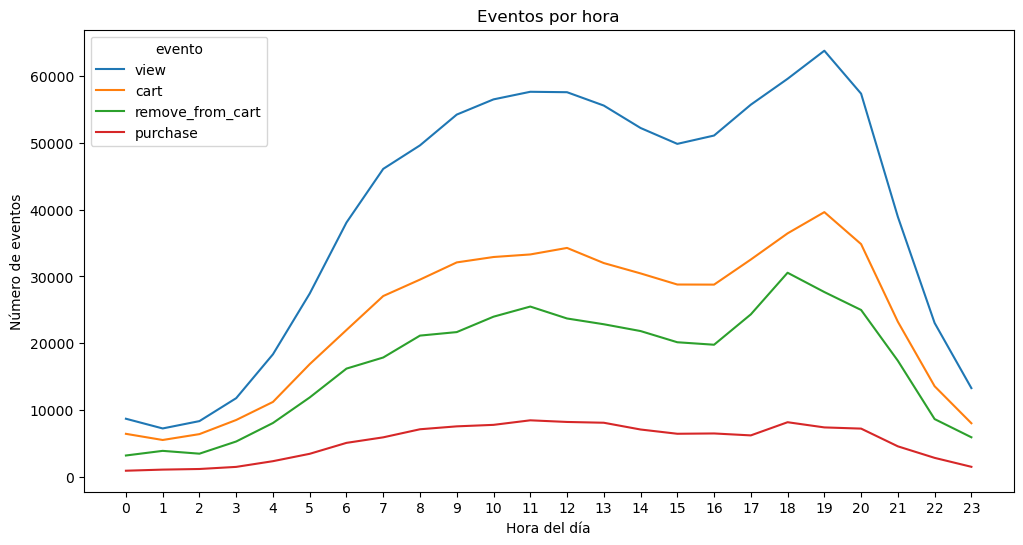

In [33]:
eventos_hora.plot(figsize = (12,6))
plt.title("Eventos por hora")
plt.xlabel("Hora del día")
plt.ylabel("Número de eventos")
plt.xticks(ticks=eventos_hora.index, labels=eventos_hora.index)
plt.show();

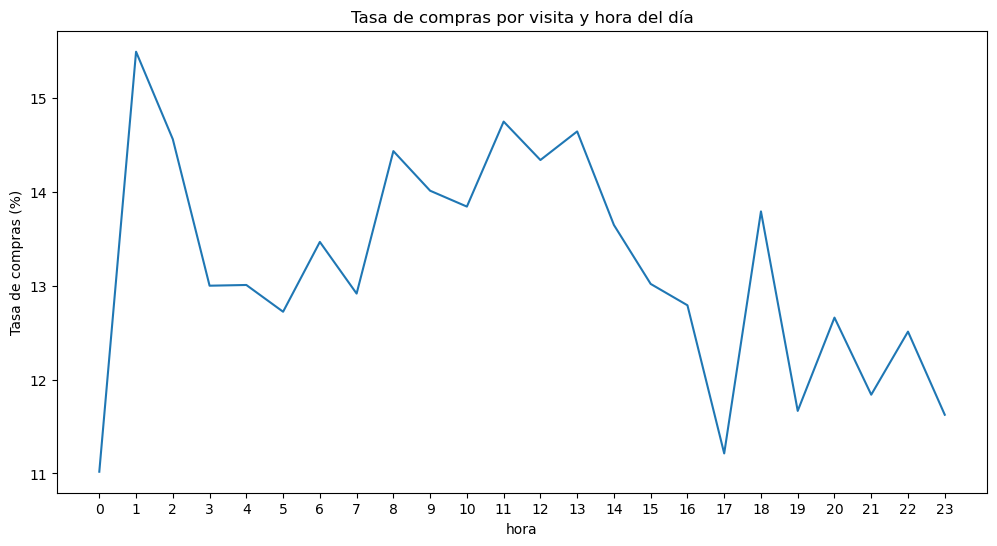

In [34]:
eventos_hora['compras_visita'] = eventos_hora['purchase'] / eventos_hora['view']*100
eventos_hora['compras_visita'].plot(figsize = (12,6))
plt.title("Tasa de compras por visita y hora del día")
plt.ylabel("Tasa de compras (%)")
plt.xticks(ticks=eventos_hora.index, labels=eventos_hora.index)
plt.show()

**Insight 2:**

* Existen claras diferencias de comportamiento entre horas
* Las horas pico en las que que nuestros usuarios ven más páginas y añaden más al carrito son entre las 09 y las 13, y entre las 18 y las 20
* Las horas valle en las que que nuestros usuarios ven menos páginas y añaden menos al carrito son entre las 21 y las 08, y entre las 14 y las 16
* Sin embargo las horas en las que más se compra son entre las 08 y las 13, y a las 18

Acciones operativas:

* Dividir las campañas publicitarias entre tráfico frío y retargeting
* Concentrar las de tráfico frío entre 09 y las 13, y entre las 18 y las 20. Reduciendo el presupuesto fuera de ese horario.
* Concentrar las de retargeting entre las 08 y las 13, y a las 18. Reduciendo el presupuesto fuera de ese horario.

In [36]:
eventos_hora

evento,view,cart,remove_from_cart,purchase,compras_visita
hora,,,,,
0,8731,6475,3238,962,11.018211
1,7280,5555,3930,1128,15.494505
2,8378,6433,3509,1220,14.561948
3,11807,8544,5331,1535,13.000762
4,18365,11242,8095,2389,13.008440
5,27438,16890,11913,3491,12.723231
6,38055,21993,16223,5125,13.467350
7,46072,27069,17883,5951,12.916739
8,49587,29526,21156,7158,14.435235


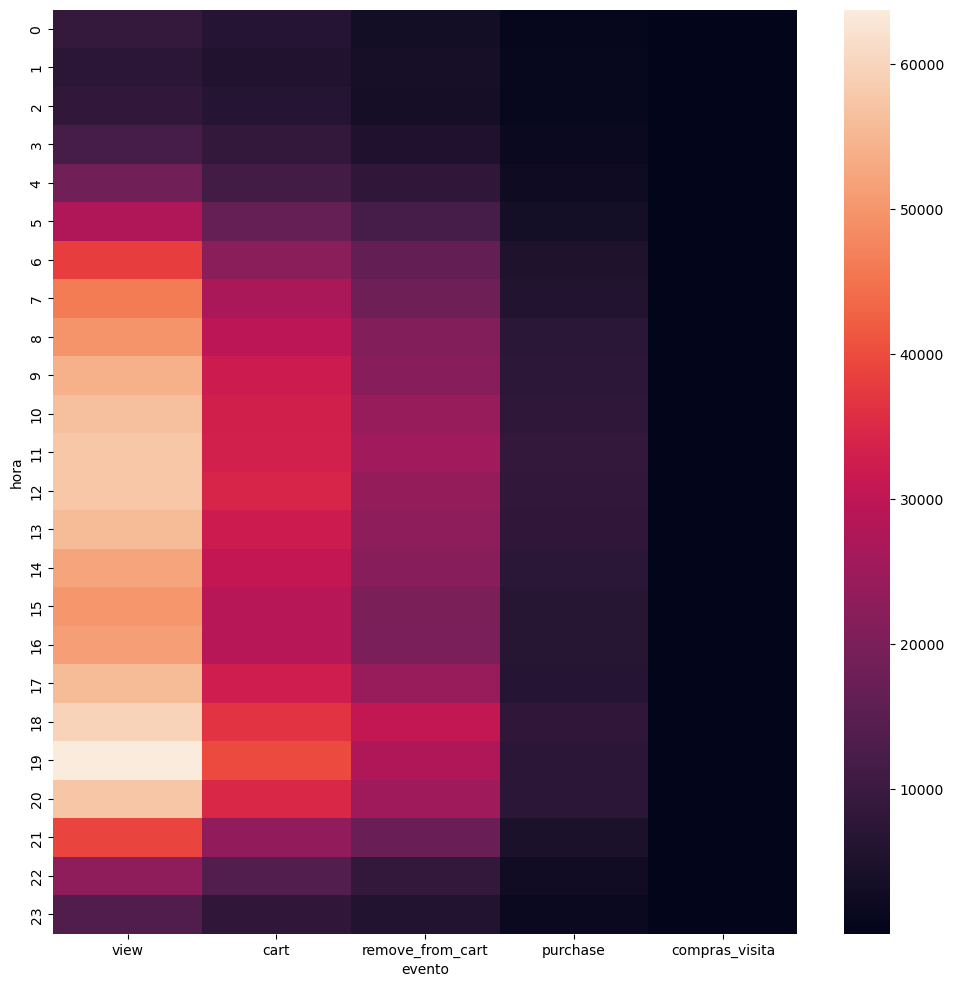

In [35]:
plt.figure(figsize= (12,12))
sns.heatmap(eventos_hora)
plt.show()

In [37]:
# Dado que las variables tienen distintas escalas el mapa de calor no permite identificar bien los insights.
# Para evitar dicho problema tipificamos las variables de eventos_hora
def tipificar(variable):
    return (variable - variable.mean()) / variable.std()

In [38]:
eventos_hora_tip = eventos_hora.apply(tipificar)
eventos_hora_tip

evento,view,cart,remove_from_cart,purchase,compras_visita
hora,,,,,
0,-1.602852,-1.557777,-1.625861,-1.622277,-1.831514
1,-1.677076,-1.639838,-1.544686,-1.560415,1.912769
2,-1.620909,-1.561523,-1.594071,-1.526129,1.132713
3,-1.445502,-1.373228,-1.380343,-1.408739,-0.173171
4,-1.110035,-1.132575,-1.056114,-1.090483,-0.166748
5,-0.645916,-0.628790,-0.608247,-0.679805,-0.405317
6,-0.102815,-0.173618,-0.102666,-0.070869,0.217116
7,0.307286,0.279146,0.092059,0.236953,-0.243453
8,0.487092,0.498303,0.475996,0.686761,1.026722


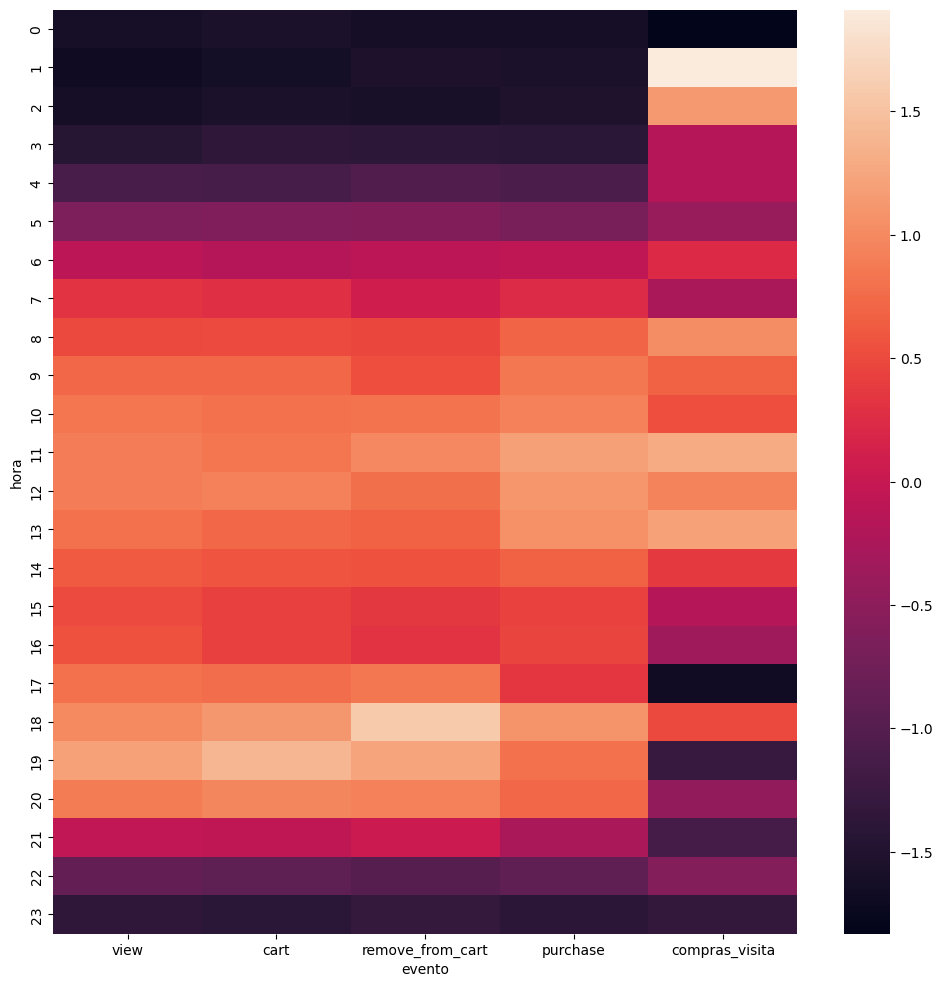

In [39]:
# Ahora volvemos a hacer el heatmap
plt.figure(figsize=(12,12))
sns.heatmap(eventos_hora_tip);

In [41]:
df_purchase = df.loc[df['evento']=='purchase']
df_purchase

,usuario,sesion,evento,categoria,producto,precio,año,mes,dia,hora,...,trimestre,fecha,festivo,dia_singles_11nov,dia_unidad_nacional_4nov,black_friday_2019,cyber_monday_2019,periodo_fin_ano_nuevo_ano,navidad_ortodoxa_7ene,defensor_patria_23feb
fecha_hora,,,,,,,,,,,,,,,,,,,,,
2019-10-01 00:26:49+00:00,536128518,a31f0991-645e-4472-a012-95eb2f814568,purchase,1487580006317032337,5887011,1.59,2019,10,1,0,...,4,2019-10-01,0,0,0,0,0,0,0,0
2019-10-01 00:26:49+00:00,536128518,a31f0991-645e-4472-a012-95eb2f814568,purchase,1487580006317032337,34767,1.35,2019,10,1,0,...,4,2019-10-01,0,0,0,0,0,0,0,0
2019-10-01 00:26:49+00:00,536128518,a31f0991-645e-4472-a012-95eb2f814568,purchase,1487580006317032337,34768,1.35,2019,10,1,0,...,4,2019-10-01,0,0,0,0,0,0,0,0
2019-10-01 00:26:49+00:00,536128518,a31f0991-645e-4472-a012-95eb2f814568,purchase,1487580009362096156,5584,1.11,2019,10,1,0,...,4,2019-10-01,0,0,0,0,0,0,0,0
2019-10-01 00:26:49+00:00,536128518,a31f0991-645e-4472-a012-95eb2f814568,purchase,1487580006317032337,5588612,3.97,2019,10,1,0,...,4,2019-10-01,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-02-29 22:29:19+00:00,622065819,a6c280be-ad01-413d-818e-a818f3ac3558,purchase,1487580006409307030,5659905,2.86,2020,2,29,22,...,1,2020-02-29,0,0,0,0,0,0,0,0
2020-02-29 22:29:19+00:00,622065819,a6c280be-ad01-413d-818e-a818f3ac3558,purchase,1487580006409307030,5659911,2.86,2020,2,29,22,...,1,2020-02-29,0,0,0,0,0,0,0,0
2020-02-29 22:29:19+00:00,622065819,a6c280be-ad01-413d-818e-a818f3ac3558,purchase,1487580006409307030,5697535,2.86,2020,2,29,22,...,1,2020-02-29,0,0,0,0,0,0,0,0


In [46]:
compras_por_mes = df_purchase.groupby(['mes'])['precio'].sum()
print(compras_por_mes)
print("media_compras_por_mes=", compras_por_mes.mean())

mes
1     135174.45
2     121330.67
10    116519.04
11    146491.24
12    102034.20
Name: precio, dtype: float64
media_compras_por_mes= 124309.92


In [47]:
# Es extraño que diciembre es más bajo que noviembre, se puede deber al black friday de noviembre.
# Es habitual que mucha gente adelante las compras de Navidad y lo haga en noviembre con ofertas de BF.

COMPRAS POR SEMANA

In [ ]:
# Agrupar por evento y semana, mostrando solo la fecha de inicio de cada semana. Hacemos resample (res)
df_temp = df.copy()
df_temp['fecha'] = pd.to_datetime(df_temp['fecha'])
res = df_temp.set_index('fecha').groupby('evento').resample('W').size().unstack(level=0)
res.index = res.index.strftime('%Y-%m-%d')
res

evento,cart,purchase,remove_from_cart,view
fecha,,,,
2019-10-06,31483,4440,14647,36353
2019-10-13,28151,5422,17989,44410
2019-10-20,23920,5033,15303,39486
2019-10-27,25651,5665,18411,40383
2019-11-03,24087,5746,16491,39365
2019-11-10,29142,6663,24008,46177
2019-11-17,25335,5141,17215,41170
2019-11-24,38069,9754,27973,56477
2019-12-01,31994,7493,23106,48883


In [52]:
# damos el orden que queremos
res = res[['view','cart','remove_from_cart','purchase']]
res

evento,view,cart,remove_from_cart,purchase
fecha,,,,
2019-10-06,36353,31483,14647,4440
2019-10-13,44410,28151,17989,5422
2019-10-20,39486,23920,15303,5033
2019-10-27,40383,25651,18411,5665
2019-11-03,39365,24087,16491,5746
2019-11-10,46177,29142,24008,6663
2019-11-17,41170,25335,17215,5141
2019-11-24,56477,38069,27973,9754
2019-12-01,48883,31994,23106,7493


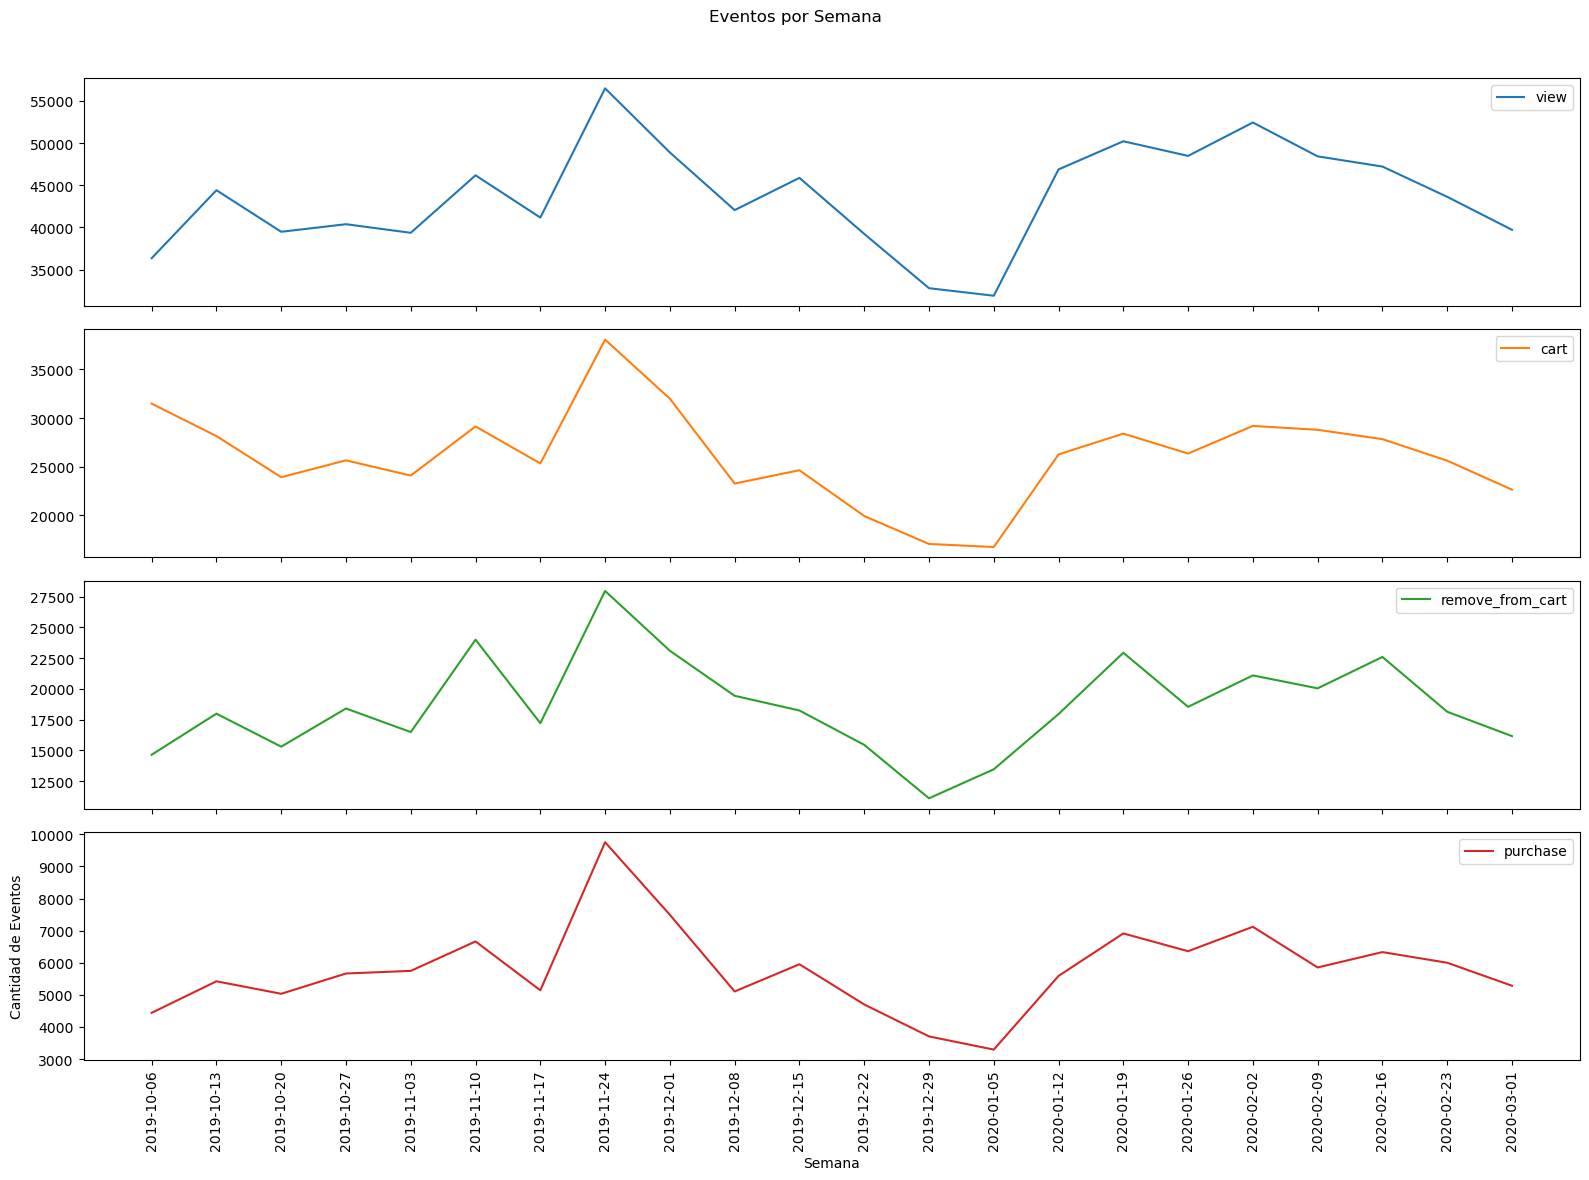

In [53]:
res.plot(subplots=True, figsize=(16,12))
plt.suptitle('Eventos por Semana')
plt.xlabel('Semana')
plt.ylabel('Cantidad de Eventos')
plt.xticks(ticks=range(len(res.index)), labels=res.index, rotation=90)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


ANÁLISIS DIARIO DE LOS MESES DE NOVIEMBRE Y DICIEMBRE

In [56]:
# Agrupar por evento y día en los meses de noviembre y diciembre
df_temp = df.copy()
df_temp['fecha'] = pd.to_datetime(df_temp['fecha'])
res_dia = df_temp.set_index('fecha').loc['2019-11':'2019-12'].groupby('evento').resample('D').size().unstack(level=0)
res_dia.index = res_dia.index.strftime('%Y-%m-%d')
res_dia = res_dia[['view','cart','remove_from_cart','purchase']]
res_dia

evento,view,cart,remove_from_cart,purchase
fecha,,,,
2019-11-01,5352,3565,2810,709
2019-11-02,4857,3015,2124,912
2019-11-03,5583,3540,2622,755
2019-11-04,6248,4652,4854,676
2019-11-05,7213,4118,2711,753
...,...,...,...,...
2019-12-27,4058,2023,1335,507
2019-12-28,3704,1744,1193,329
2019-12-29,3939,2134,1149,263


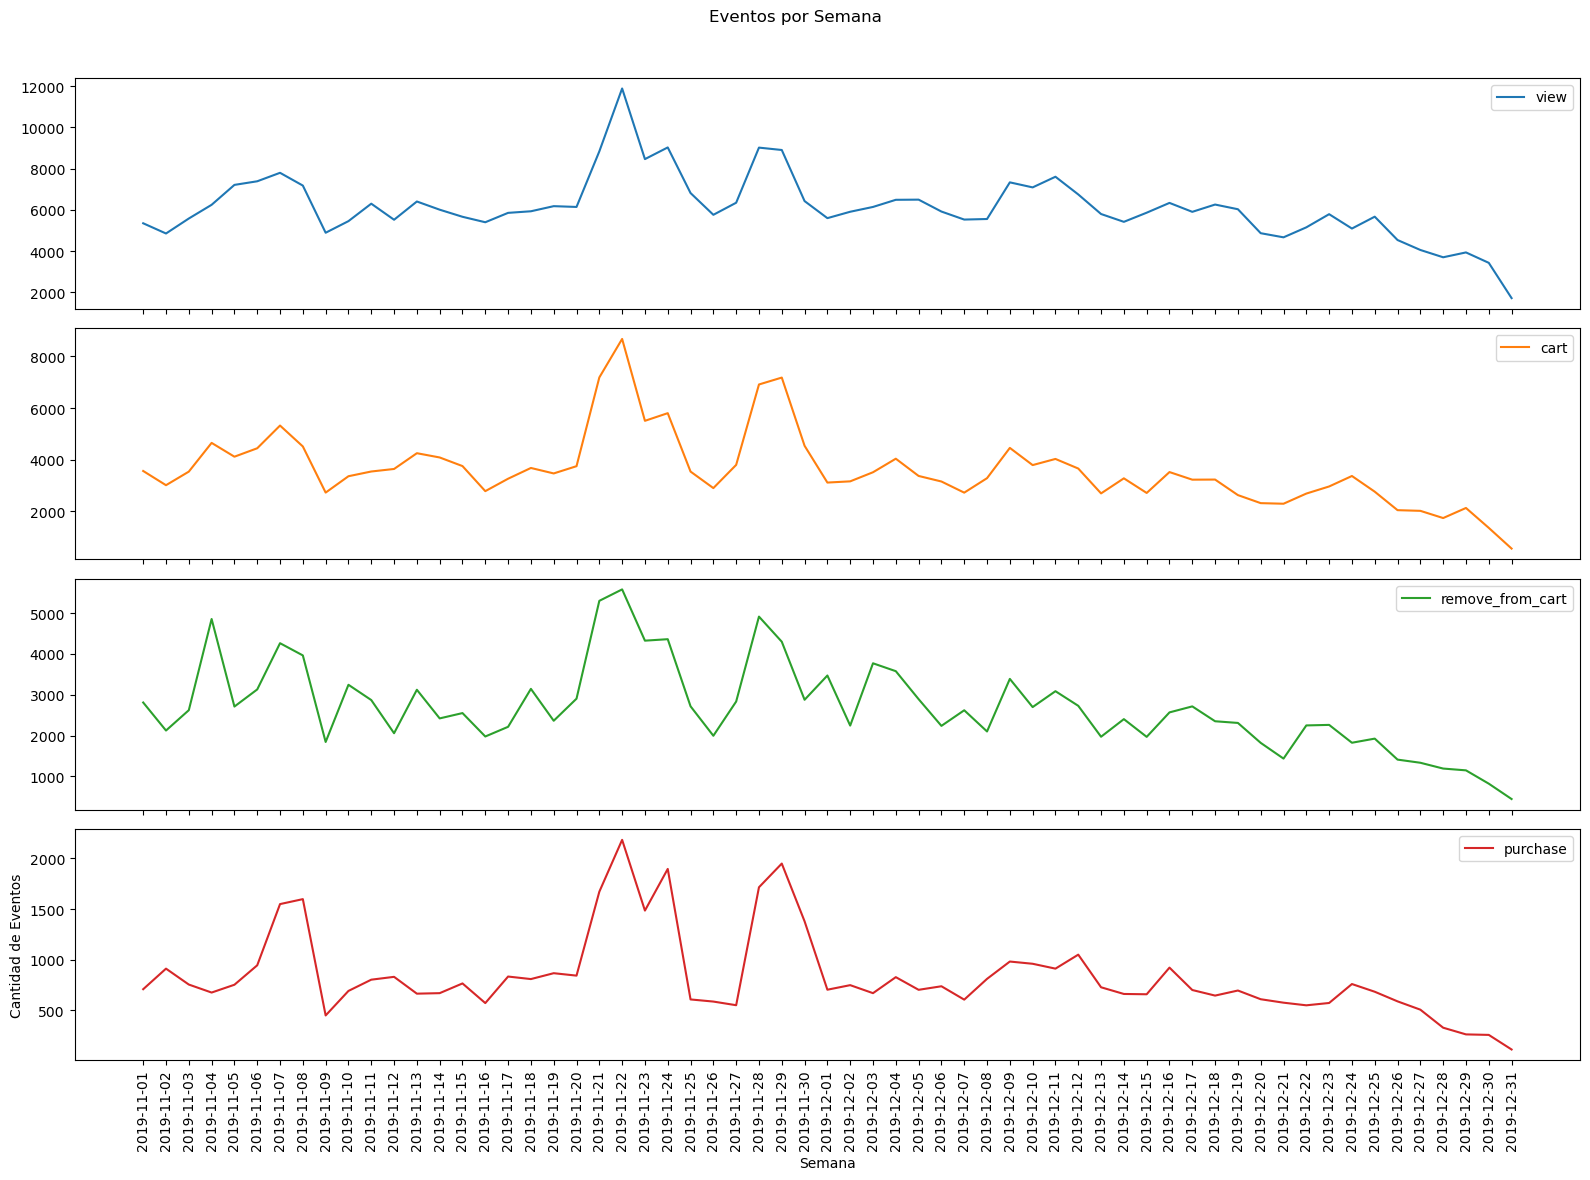

In [57]:
res_dia.plot(subplots=True, figsize=(16,12))
plt.suptitle('Eventos por Semana')
plt.xlabel('Semana')
plt.ylabel('Cantidad de Eventos')
plt.xticks(ticks=range(len(res_dia.index)), labels=res_dia.index, rotation=90)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Análisis de clientes (marketing y CRM)

Tabla **`clientes`**: una fila por `usuario` con al menos una compra (`evento == 'purchase'`), agregada desde el tablón.

La siguiente celda calcula métricas y responde a estas preguntas (ajustadas al dataset):

1. **Concentración del valor (Pareto):** ¿qué parte del gasto total concentran el 20 % de clientes con mayor gasto?
2. **Una compra vs repetidores:** ¿cuántos clientes compran una sola vez y qué % del gasto aportan los repetidores?
3. **Distribución del gasto y del ticket medio** por cliente.
4. **Recencia:** días desde la última compra hasta el fin del periodo observado (base para win-back).
5. **Ventana de actividad:** días entre primera y última compra (clientes con más de una compra).
6. **Diversidad de categorías** compradas por cliente (oportunidad de cross-sell).
7. **Fricción previa:** relación entre `cart` / `remove_from_cart` y compras por usuario (proxy de abandono).
8. **Compras en días “especiales”** (flags de calendario en el tablón): ¿qué % de clientes tiene al menos una compra en esos días?
9. **Cohortes simples por mes de primera compra:** tamaño de cohorte y tasa de clientes que repiten en otro mes distinto.
10. **Segmentación RFM simplificada** (terciles): etiquetas orientativas (campeones, leales, en riesgo, perdidos).
11. **Perfiles alto gasto / muchas compras** vs **pocas compras y ticket alto** (cuartiles cruzados).
12. **Resumen ejecutivo** para priorizar CRM.

El informe en Markdown se guarda en **`docs/analisis_clientes.md`**.


In [ ]:
# Tabla `clientes` (una fila por usuario comprador) + informe `docs/analisis_clientes.md`
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path("..").resolve()
DOC = ROOT / "docs" / "analisis_clientes.md"

df["fecha"] = pd.to_datetime(df["fecha"])
fin_periodo = df["fecha"].max()
pur = df.loc[df["evento"] == "purchase"].copy()

clientes = (
    pur.groupby("usuario", as_index=False)
    .agg(
        compras=("precio", "count"),
        gasto=("precio", "sum"),
        precio_medio=("precio", "mean"),
        productos=("producto", "nunique"),
        categorias=("categoria", "nunique"),
        primera_compra=("fecha", "min"),
        ultima_compra=("fecha", "max"),
    )
)
clientes["productos_por_compra"] = clientes["productos"] / clientes["compras"]
clientes["dias_primera_ultima"] = (
    (clientes["ultima_compra"] - clientes["primera_compra"]).dt.days
)

ev = (
    df.groupby(["usuario", "evento"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=lambda c: f"evt_{c}")
)
clientes = clientes.merge(ev, on="usuario", how="left")

clientes["recencia_dias"] = (fin_periodo - clientes["ultima_compra"]).dt.days

flag_cols = [
    c
    for c in df.columns
    if c
    in (
        "festivo",
        "dia_singles_11nov",
        "dia_unidad_nacional_4nov",
        "black_friday_2019",
        "cyber_monday_2019",
        "periodo_fin_ano_nuevo_ano",
        "navidad_ortodoxa_7ene",
        "defensor_patria_23feb",
    )
]
pur["compra_especial"] = (pur[flag_cols].sum(axis=1) > 0).astype(int)
esp = pur.groupby("usuario")["compra_especial"].max().rename("compra_en_dia_especial")
clientes = clientes.merge(esp, on="usuario", how="left")

n_clientes = len(clientes)
gasto_total = clientes["gasto"].sum()

orden_gasto = clientes.sort_values("gasto", ascending=False).reset_index(drop=True)
orden_gasto["gasto_acum"] = orden_gasto["gasto"].cumsum()
top20_idx = max(1, int(np.ceil(0.20 * n_clientes)))
pareto20_pct = float(
    orden_gasto.loc[orden_gasto.index < top20_idx, "gasto"].sum() / gasto_total * 100
)

una_compra = clientes["compras"] == 1
n_una = int(una_compra.sum())
n_rep = int((~una_compra).sum())
gasto_una = float(clientes.loc[una_compra, "gasto"].sum())
gasto_rep = float(clientes.loc[~una_compra, "gasto"].sum())
pct_gasto_rep = 100 * gasto_rep / gasto_total if gasto_total else 0

prim_mes = pur.groupby("usuario")["fecha"].min().dt.to_period("M")
meses_dist = pur.groupby("usuario")["fecha"].apply(lambda s: s.dt.to_period("M").nunique())
rep_otro_mes = []
for m in sorted(prim_mes.unique()):
    uids = prim_mes[prim_mes == m].index
    rep_otro_mes.append(
        {
            "cohorte_mes": str(m),
            "n_clientes": len(uids),
            "pct_repiten_otro_mes": round(
                100 * float((meses_dist.reindex(uids) > 1).mean()), 2
            ),
        }
    )
cohorte_df = pd.DataFrame(rep_otro_mes)

clientes["R"] = pd.qcut(
    clientes["recencia_dias"].rank(method="first"),
    q=3,
    labels=[3, 2, 1],
    duplicates="drop",
)
clientes["F"] = pd.qcut(
    clientes["compras"].rank(method="first"), q=3, labels=[1, 2, 3], duplicates="drop"
)
clientes["M"] = pd.qcut(
    clientes["gasto"].rank(method="first"), q=3, labels=[1, 2, 3], duplicates="drop"
)


def rfm_etiqueta(row):
    r, f, m = int(row["R"]), int(row["F"]), int(row["M"])
    if r >= 3 and f >= 3 and m >= 3:
        return "Campeones"
    if r >= 2 and f >= 2:
        return "Leales / potencial"
    if r == 1 and f >= 2:
        return "En riesgo (compraban, hace tiempo)"
    if r == 1:
        return "Perdidos / dormidos"
    return "Otros"


clientes["segmento_rfm"] = clientes.apply(rfm_etiqueta, axis=1)
seg_counts = clientes["segmento_rfm"].value_counts()

clientes["q_gasto"] = pd.qcut(
    clientes["gasto"].rank(method="first"), q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"
)
clientes["q_compras"] = pd.qcut(
    clientes["compras"].rank(method="first"),
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    duplicates="drop",
)
cruce = (
    clientes.groupby(["q_compras", "q_gasto"], observed=False)
    .size()
    .unstack(fill_value=0)
    .astype(int)
)

for col in ("evt_cart", "evt_remove_from_cart", "evt_view"):
    if col not in clientes.columns:
        clientes[col] = 0
clientes["cart_por_compra"] = clientes["evt_cart"] / clientes["compras"].replace(0, np.nan)
clientes["remove_por_compra"] = clientes["evt_remove_from_cart"] / clientes["compras"].replace(
    0, np.nan
)

pct_especial = 100 * clientes["compra_en_dia_especial"].mean()


def tbl(d):
    return "```\n" + d.to_string() + "\n```"


lines = []
lines.append("# Análisis de clientes — Ecommerce (cosmética)")
lines.append("")
lines.append(f"- **Generado:** {datetime.now().strftime('%Y-%m-%d %H:%M')}")
lines.append(
    f"- **Fuente:** `tablon_analitico.pickle`, eventos `purchase`; periodo hasta `{fin_periodo.date()}`. "
)
lines.append(f"- **Clientes con al menos una compra:** {n_clientes:,}")
lines.append("")

lines.append("## 1. Concentración del valor (Pareto)")
lines.append(
    f"- El **20 %** de clientes con mayor gasto (aprox. **{top20_idx:,}** clientes) concentran el **{pareto20_pct:.1f} %** del gasto total."
)
lines.append("")

lines.append("## 2. Compradores de una sola vez vs repetidores")
lines.append(
    f"- **Una sola compra:** {n_una:,} clientes ({100 * n_una / n_clientes:.1f} % del universo); aportan **{100 * gasto_una / gasto_total:.1f} %** del gasto."
)
lines.append(
    f"- **Repetidores (más de una compra):** {n_rep:,} ({100 * n_rep / n_clientes:.1f} %); aportan **{pct_gasto_rep:.1f} %** del gasto."
)
lines.append("")

lines.append("## 3. Distribución del gasto y ticket por cliente")
lines.append(tbl(clientes[["gasto", "precio_medio", "compras"]].describe()))
lines.append("")

lines.append("## 4. Recencia (días hasta fin de periodo)")
lines.append(
    f"- Media: **{clientes['recencia_dias'].mean():.1f}** días | Mediana: **{clientes['recencia_dias'].median():.1f}**"
)
lines.append("")

lines.append("## 5. Ventana primera–última compra (solo con >1 compra)")
solo_rep = clientes[clientes["compras"] > 1]
lines.append(
    f"- Clientes con >1 compra: **{len(solo_rep):,}**; media de días entre primera y última: **{solo_rep['dias_primera_ultima'].mean():.1f}**"
)
lines.append("")

lines.append("## 6. Diversidad de categorías (compras)")
lines.append(
    f"- Media de categorías distintas compradas por cliente: **{clientes['categorias'].mean():.2f}** | mediana: **{clientes['categorias'].median():.0f}**"
)
lines.append("")

lines.append("## 7. Fricción (eventos de carrito vs compras)")
lines.append(
    f"- Media de `cart` / compra: **{clientes['cart_por_compra'].mean():.2f}** | media de `remove_from_cart` / compra: **{clientes['remove_por_compra'].mean():.2f}**"
)
lines.append(
    "  - *Interpretación:* valores altos sugieren exploración o abandono frecuente antes de cerrar la compra."
)
lines.append("")

lines.append("## 8. Compras en días especiales (flags del calendario)")
lines.append(
    f"- **{pct_especial:.1f} %** de clientes tienen al menos una línea de compra en un día marcado por algún flag (festivo / campañas)."
)
lines.append("")

lines.append("## 9. Cohortes por mes de primera compra")
lines.append(tbl(cohorte_df))
lines.append("")
lines.append(
    "- **pct_repiten_otro_mes:** % de clientes de esa cohorte con compras en **más de un mes distinto** (proxy de repetición en el tiempo)."
)
lines.append("")

lines.append("## 10. Segmentación RFM simplificada (terciles)")
lines.append(tbl(seg_counts.to_frame("n_clientes")))
lines.append("")

lines.append("## 11. Cruce cuartiles: nº de compras (fila) × gasto (columna)")
lines.append(tbl(cruce))
lines.append("")

lines.append("## 12. Resumen para marketing")
lines.append(
    "- Priorizar **retención y frecuencia** si el gasto está muy concentrado y muchos clientes son de una sola compra."
)
lines.append(
    "- Segmentos **en riesgo / perdidos** con recencia alta: campañas de **win-back** y ofertas temporales."
)
lines.append(
    "- Clientes con **muchas categorías** ya compradas: bundles y recomendaciones; con **poca diversidad**: cross-sell por categoría."
)
lines.append(
    "- Calibrar **promos en días especiales** según el % de clientes que ya compran en esas fechas (evitar canibalización)."
)
lines.append("")

DOC.parent.mkdir(parents=True, exist_ok=True)
DOC.write_text("\n".join(lines), encoding="utf-8")
print("Informe escrito:", DOC.resolve())
display(clientes.head(10))
clientes.describe()
